# Imports and read data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

%matplotlib widget
plt.rc('text', usetex = True)
plt.rcParams['figure.facecolor'] = 'w'
plt.style.use('classic')

def customCMAP(names = ['hot_r', 'cool', 'bone_r', 'pink_r', 'plasma_r'], ncolors: int = 256):

        for cmap in names:
            # if custom version of cmap already exists, skip it
            if cmap + 'T' in plt.colormaps():
                continue
            else:
            # create the colormap
                color_array = plt.get_cmap(cmap)(range(ncolors))
                color_array[:,-1] = np.power(np.linspace(0, 1.0, ncolors), 1/2) # adjusted so that the alpha increases quicker than linearly
                map_object = mcolors.LinearSegmentedColormap.from_list(name = cmap + 'T', colors = color_array)
                plt.register_cmap(cmap = map_object)

customCMAP()

# Electron charge in C
e_charge = 1.602176634e-19

# ILC parameters
n_incident = 2.5e10
n_bunches = 1312
ILC_scale = n_bunches * n_incident

density = {
    'LXe': 2.953 * 1e6, # g/m^3
    'Be' : 1.848 * 1e6, # g/m^3
    'Al' : 2.699 * 1e6, # g/m^3
}

# n_electrons_per_pulse = n_incident / 20 # 20 beam pulses per bunch train WRONG ==> 1.25e9 e- per pulse
n_electrons_per_pulse = 66 * n_incident # 2.5e10 e- per bunch, 66 bunches in a pulse
pulse_time_sep = 3.3e-3 # 3.3 ms between pulses


In [14]:
scaled = False
material = 'Be'
thickness = '0.5'
path = f'/Users/max/SLAC Fall 2024/LXeSims/{material}_sigmaR_3mm_thickness_{thickness}mm'

cols = 'x y z Px Py Pz t PDGid EventID TrackID ParentID Weight'.split(' ')

df_LXe = pd.read_csv(path + '/LXe.csv')
df_Entrance = pd.read_csv(path + '/entrance_window.csv')
df_Exit = pd.read_csv(path + '/exit_window.csv')

df_shower = pd.read_csv(path + '/zWinDet.txt', skiprows=2, header=0, delim_whitespace=True, names=cols)

## Determine positron yield from outgoing shower

In [119]:
positron_mask = df_shower['PDGid'] == -11
positrons = df_shower[positron_mask]
total_yeid = positrons.size / positrons.columns.size
normalized_total_yield = total_yeid / 1e3

# E = √( p^2 c^2 + (mc^2)^2)
energy = np.sqrt(positrons['Pz']**2 + 0.511**2) # MeV
r = np.sqrt(positrons['x']**2 + positrons['y']**2)

sigma = 3
std = sigma * np.random.randn(positrons['x'].size, 2)
x = positrons['x'] + std[:, 0]
y = positrons['y'] + std[:, 1]
t = np.sqrt(x**2 + y**2)

E_low  = 2 # MeV
E_high = 22 # MeV
radius = 10 # mm

selection_mask = (r < radius) & (energy > E_low) & (energy < E_high)
conv_t_mask = (t < radius) & (energy > E_low) & (energy < E_high)

# plt.close()
# plt.figure()
# plt.hist(energy, bins=30, rwidth=0.8, color='skyblue', edgecolor='black')
# plt.xlabel(r'$\mathrm{Energy}\ [\mathrm{MeV}]$', fontsize=16)
# plt.show()

### LXe paper:
For the ILC case, we select the beam parameters from the most recent electron beam-driven source design at 3 GeV, which assumes a target-to-damping ring yield of 1.2, and 50% overhead of particles delivered to the damping ring [17].

For the convolved transverse width case, all normalized $e^+$ yields are between 1.8-ish and 2.0, $\\$ so it's probably a safe bet to stick with the 1.8 @ 50% overhead $\implies$ 1.2 yield $\implies$ $2.5\times 10^{10}\ e^-$ per bunch train. 

In [120]:
selected_yield = energy[selection_mask].size / 1e3
print(f'{4.8e-9 / e_charge / selected_yield:.2e}')
print(f'{4.8e-9 / e_charge / 1.2:.2e}')
print(f'Total normalized e+ yield: {normalized_total_yield:.2f}')
print(f'Selected normalized e+ yield: {energy[selection_mask].size/1e3:.2f}')
print(f'Selected conv. normalized e+ yield: {energy[conv_t_mask].size/1e3:.2f}')

1.40e+10
2.50e+10
Total normalized e+ yield: 6.24
Selected normalized e+ yield: 2.13
Selected conv. normalized e+ yield: 1.93


# Convert EDD to W/m^3

In [15]:
window_scale_and_conversion_factor = (1 / ILC_scale) * n_electrons_per_pulse * density[material] / pulse_time_sep
LXe_scale_and_conversion_factor = (1 / ILC_scale) * n_electrons_per_pulse * density['LXe'] / pulse_time_sep
#                                  ^ normalize      ^ scale to beam pulse   ^ (J/g) * g/m^3 * 1/s = W/m^3

# 0.5mm-thick window subvolume = 0.0005 cm^3 = 0.0000000005 m^3
# LXe subvolume = 0.002 cm^3 = 0.000000002 m^3

if not scaled:
    scaled = True
    
    df_LXe['EDD'     ] *= LXe_scale_and_conversion_factor
    df_Entrance['EDD'] *= window_scale_and_conversion_factor
    df_Exit['EDD'    ] *= window_scale_and_conversion_factor

    # convert x,y,z [cm] to [m]
    for df in [df_LXe, df_Entrance, df_Exit]:
        df['x']*= 1e-2
        df['y']*= 1e-2
        df['z']*= 1e-2

### Power loss

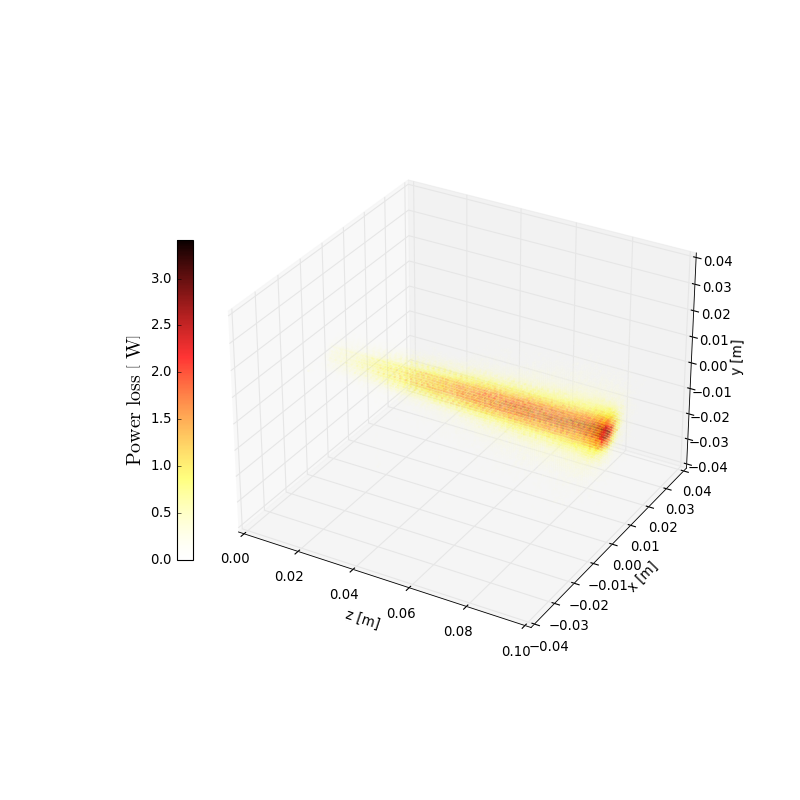

In [6]:
X,Y = np.meshgrid(np.unique(df_LXe['x']), np.unique(df_LXe['y']))

plt.close()
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10,10))
img = ax.scatter(df_LXe['z'], df_LXe['x'], df_LXe['y'], c=df_LXe['EDD']*0.0000000005, marker='o', s=5, cmap='hot_rT', edgecolors='none')
ax.scatter(df_Entrance['z'], df_Entrance['x'], df_Entrance['y'], c=df_Entrance['EDD']*0.000000002, marker='o', s=5, cmap='coolT', edgecolors='none', vmax = 4e9)
ax.scatter(df_Exit['z'], df_Exit['x'], df_Exit['y'], c=df_Exit['EDD']*0.000000002, marker='o', s=5, cmap='coolT', edgecolors='none', vmax = 4e9)

cb = fig.colorbar(img, ax=ax, pad=0.01, shrink=.5, location='left')
cb.set_label(label=r'$\mathrm{Power\ loss}\ \left[\ \mathrm{W}\right]$', fontsize=18)
cb.formatter.set_useMathText(True)
cb.formatter.set_powerlimits((0, 0))

ax.set_xlabel('z [m]')
ax.set_ylabel('x [m]')
ax.set_zlabel('y [m]')

ax.set_xlim(0, 0.1)

plt.show()

### Power loss per volume

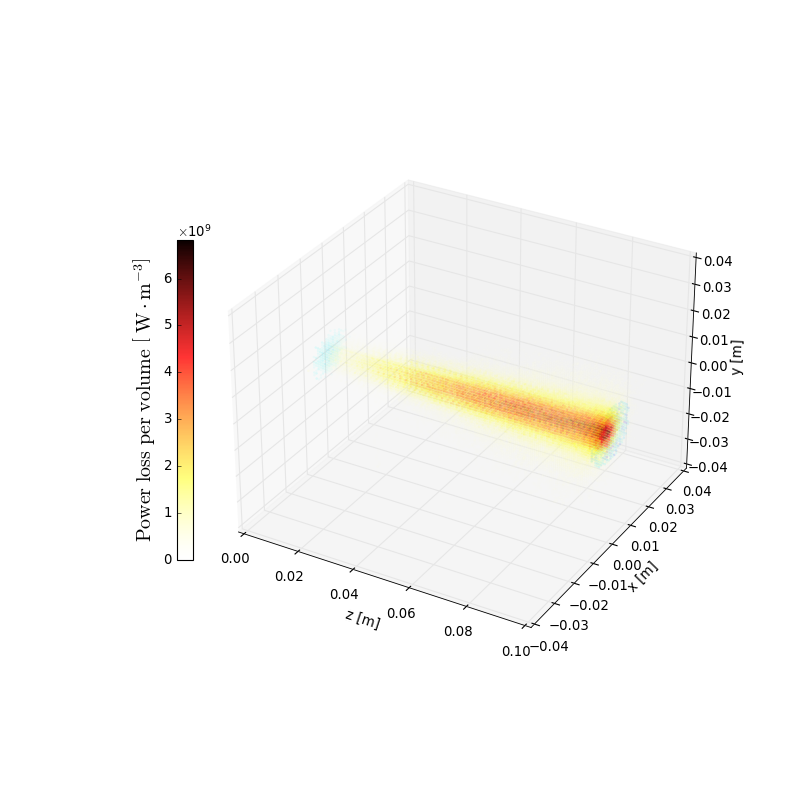

In [16]:
X,Y = np.meshgrid(np.unique(df_LXe['x']), np.unique(df_LXe['y']))

plt.close()
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10,10))
img = ax.scatter(df_LXe['z'], df_LXe['x'], df_LXe['y'], c=df_LXe['EDD'], marker='o', s=5, cmap='hot_rT', edgecolors='none')
ax.scatter(df_Entrance['z'], df_Entrance['x'], df_Entrance['y'], c=df_Entrance['EDD'], marker='o', s=5, cmap='coolT', edgecolors='none', vmax = 4e9)
ax.scatter(df_Exit['z'], df_Exit['x'], df_Exit['y'], c=df_Exit['EDD'], marker='o', s=5, cmap='coolT', edgecolors='none', vmax = 4e9)

cb = fig.colorbar(img, ax=ax, pad=0.01, shrink=.5, location='left')
cb.set_label(label=r'$\mathrm{Power\ loss\ per\ volume}\ \left[\ \mathrm{W}\cdot \mathrm{m}^{-3}\right]$', fontsize=18)
cb.formatter.set_useMathText(True)
cb.formatter.set_powerlimits((0, 0))

ax.set_xlabel('z [m]')
ax.set_ylabel('x [m]')
ax.set_zlabel('y [m]')

ax.set_xlim(0, 0.1)

plt.show()

# Export data

In [17]:
df_LXe.rename(     columns={'x': 'x', 'y': 'y', 'z': 'z', 'EDD': 'PowerPerVolume'}).to_csv(path+"/Silviu_LXe.csv",             index=False)
df_Entrance.rename(columns={'x': 'x', 'y': 'y', 'z': 'z', 'EDD': 'PowerPerVolume'}).to_csv(path+"/Silviu_entrance_window.csv", index=False)
df_Exit.rename(    columns={'x': 'x', 'y': 'y', 'z': 'z', 'EDD': 'PowerPerVolume'}).to_csv(path+"/Silviu_exit_window.csv",     index=False)